In [6]:
import duckdb
import pandas as pd

# Conectar a tu base
con = duckdb.connect("C:/Users/jrf24/Incendios-Forestales-/data/BaseDeDatos_Working.db")

In [7]:
df = con.execute("SELECT * FROM dataset_final").df()

In [8]:
df.head()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12703 entries, 0 to 12702
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype          
---  ------              --------------  -----          
 0   id_clave_inc        12703 non-null  str            
 1   id_cvegeo           12703 non-null  str            
 2   anio                12703 non-null  int32          
 3   id_causa            12703 non-null  int32          
 4   id_vegetacion       12703 non-null  int32          
 5   tamanio             12703 non-null  str            
 6   hojarasca           12703 non-null  float32        
 7   arbustivo           12703 non-null  float32        
 8   herbaceo            12703 non-null  float32        
 9   arbolado_adulto     12703 non-null  float32        
 10  duracion_hhmm       12391 non-null  timedelta64[us]
 11  duracion_dias       0 non-null      Int32          
 12  nombre_municipio    12703 non-null  str            
 13  tipo_de_vegetacion  12703 non-null  str   

## Análisis de correlación inicial

Se calcula la matriz de correlación entre variables numéricas.

¿Qué es la correlación?
Es una medida estadística que indica qué tan relacionadas están dos variables:
- +1 → relación positiva fuerte
- 0 → sin relación
- -1 → relación negativa fuerte

 Objetivo: dentificar variables que tienen mayor relación entre sí y posibles variables predictoras importantes.

In [54]:
df.corr(numeric_only=True)

,anio,id_causa,id_vegetacion,hojarasca,arbustivo,herbaceo,arbolado_adulto,duracion_dias,temp_prom,humedad_prom,viento_prom,temp_max,duracion_horas,tamanio_num
anio,1.000000,-0.083109,0.246372,4.097745e-02,0.107191,0.107369,0.018211,NaN,3.074886e-02,-1.406965e-01,-6.599492e-02,8.850354e-02,0.204768,0.212038
id_causa,-0.083109,1.000000,-0.003107,-7.361312e-03,-0.025716,-0.045109,-0.013055,NaN,1.657434e-03,-1.820709e-03,6.750265e-03,7.360256e-03,-0.035165,-0.071334
id_vegetacion,0.246372,-0.003107,1.000000,9.305194e-03,0.041766,0.012107,0.022591,NaN,4.783852e-02,-8.098632e-02,2.443566e-02,7.384529e-02,0.030409,0.038799
hojarasca,0.040977,-0.007361,0.009305,1.000000e+00,0.003807,0.009531,-0.000790,NaN,2.019715e-16,5.923983e-16,-1.085099e-16,1.714745e-09,0.022049,0.043905
arbustivo,0.107191,-0.025716,0.041766,3.806811e-03,1.000000,0.572091,0.288944,NaN,4.583403e-02,-3.230776e-02,1.130765e-02,4.931561e-02,0.234819,0.563388
herbaceo,0.107369,-0.045109,0.012107,9.530796e-03,0.572091,1.000000,0.191259,NaN,2.575272e-02,-1.596825e-02,2.270770e-03,2.971617e-02,0.212588,0.590709
arbolado_adulto,0.018211,-0.013055,0.022591,-7.897291e-04,0.288944,0.191259,1.000000,NaN,4.085177e-03,-6.189484e-03,1.584801e-03,3.604198e-03,0.001363,0.184260
duracion_dias,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
temp_prom,0.030749,0.001657,0.047839,2.019715e-16,0.045834,0.025753,0.004085,NaN,1.000000e+00,-2.634492e-01,2.613588e-01,8.930343e-01,0.107879,0.078534
humedad_prom,-0.140696,-0.001821,-0.080986,5.923983e-16,-0.032308,-0.015968,-0.006189,NaN,-2.634492e-01,1.000000e+00,7.112323e-02,-5.105683e-01,-0.093205,-0.057730


## Limpieza de datos (valores nulos)

Se aplican dos estrategias:

1. Eliminación de registros con valores nulos (`dropna`)
2. Imputación con la media (`fillna`)

¿Por qué es importante?
Los valores nulos pueden distorsionar el cálculo de correlaciones y afectar el modelo predictivo.

 Decisión:
- Eliminar datos reduce información
- Imputar introduce estimaciones

Ambas se analizan para comparar resultados.

In [55]:
df_clean = df.dropna()
df_clean.corr(numeric_only=True)

,anio,id_causa,id_vegetacion,hojarasca,arbustivo,herbaceo,arbolado_adulto,duracion_dias,temp_prom,humedad_prom,viento_prom,temp_max,duracion_horas,tamanio_num
anio,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
id_causa,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
id_vegetacion,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
hojarasca,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
arbustivo,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
herbaceo,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
arbolado_adulto,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
duracion_dias,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
temp_prom,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
humedad_prom,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [56]:
df.fillna(df.mean(numeric_only=True), inplace=True)

,id_clave_inc,id_cvegeo,anio,id_causa,id_vegetacion,tamanio,hojarasca,arbustivo,herbaceo,arbolado_adulto,...,duracion_dias,nombre_municipio,tipo_de_vegetacion,regimen_del_fuego,temp_prom,humedad_prom,viento_prom,temp_max,duracion_horas,tamanio_num
0,15-15-0005,15033,2015,53,27,0 a 5 Hectáreas,0.0,0.30,2.70,0.00,...,<NA>,Ecatepec de Morelos,Bosque de Encino,Adaptado,11.312000,67.531999,0.88200,20.250000,1.283333,2.5
1,15-15-0013,15039,2015,15,1,0 a 5 Hectáreas,0.0,1.20,0.00,0.00,...,<NA>,Ixtapaluca,Bosque de Pino,Adaptado,10.932000,67.579000,1.57700,20.250000,4.166667,2.5
2,15-15-0025,15014,2015,45,35,0 a 5 Hectáreas,0.0,1.00,0.00,0.00,...,<NA>,Atlacomulco,Bosque de Cedro,Sensible,11.008000,63.714000,2.20400,21.350000,2.000000,2.5
3,15-15-0033,10115,2015,45,1,0 a 5 Hectáreas,0.0,1.00,0.00,0.00,...,<NA>,Tianguistenco,Bosque de Pino,Adaptado,14.518000,52.923000,1.21200,26.340000,3.083333,2.5
4,15-15-0041,15039,2015,45,1,0 a 5 Hectáreas,0.0,2.00,0.00,0.00,...,<NA>,Ixtapaluca,Bosque de Pino,Adaptado,9.868000,61.035000,1.61700,20.420000,4.250000,2.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12698,25-15-0779,15060,2025,50,33,0 a 5 Hectáreas,0.0,0.62,0.00,0.00,...,<NA>,Nicolás Romero,Bosque de Oyamel,Influido,17.434388,45.439449,1.59955,28.625711,3.416667,2.5
12699,25-15-0788,15085,2025,50,40,21 a 50 Hectáreas,0.0,28.02,7.01,7.01,...,<NA>,Temascalcingo,Bosque de Encino-Pino,Dependiente,17.434388,45.439449,1.59955,28.625711,7.166667,35.0
12700,25-15-0797,15114,2025,8,25,6 a 10 Hectáreas,0.0,5.64,0.00,0.00,...,<NA>,Villa Victoria,Bosque de Pino,Dependiente,17.434388,45.439449,1.59955,28.625711,2.833333,8.0
12701,25-15-0807,15057,2025,1,10,21 a 50 Hectáreas,0.0,25.16,0.00,0.00,...,<NA>,Naucalpan de Juárez,Bosque de Encino,Dependiente,17.434388,45.439449,1.59955,28.625711,6.500000,35.0


## Visualización de correlaciones (Heatmap)

Se utiliza un mapa de calor para visualizar la matriz de correlación.

Ventajas:
- Permite identificar rápidamente relaciones fuertes
- Facilita detectar patrones

 Interpretación:
- Colores intensos → correlación fuerte
- Colores claros → correlación débil

Esto ayuda a seleccionar variables relevantes para el modelo.

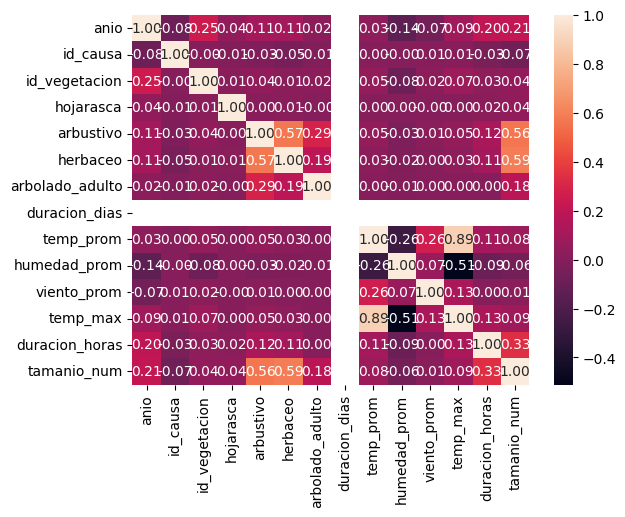

In [57]:
import matplotlib.pyplot as plt
import seaborn as sns

corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True, fmt=".2f")
plt.show()

## Resultados del analisis de correlacion 
- Se identificó una fuerte correlación entre la temperatura máxima y la temperatura promedio (r = 0.89), indicando redundancia entre ambas variables. Por lo cual es recomendable solo usar la temperatura maxima (temp_max).

- La humedad relativa presentó una correlación negativa significativa con la temperatura máxima (r = -0.51), lo que sugiere que condiciones de alta temperatura y baja humedad favorecen la propagación de incendios.

- Las variables de vegetación, particularmente cobertura arbustiva y herbácea (r = 0.57), muestran asociación con la disponibilidad de material combustible.

- La velocidad del viento mostró una correlación positiva débil con la temperatura (r = 0.26), indicando una influencia secundaria.

In [58]:
df.corr(numeric_only=True)

,anio,id_causa,id_vegetacion,hojarasca,arbustivo,herbaceo,arbolado_adulto,duracion_dias,temp_prom,humedad_prom,viento_prom,temp_max,duracion_horas,tamanio_num
anio,1.000000,-0.083109,0.246372,4.097745e-02,0.107191,0.107369,0.018211,NaN,3.074886e-02,-1.406965e-01,-6.599492e-02,8.850354e-02,0.201254,0.212038
id_causa,-0.083109,1.000000,-0.003107,-7.361312e-03,-0.025716,-0.045109,-0.013055,NaN,1.657434e-03,-1.820709e-03,6.750265e-03,7.360256e-03,-0.034597,-0.071334
id_vegetacion,0.246372,-0.003107,1.000000,9.305194e-03,0.041766,0.012107,0.022591,NaN,4.783852e-02,-8.098632e-02,2.443566e-02,7.384529e-02,0.030049,0.038799
hojarasca,0.040977,-0.007361,0.009305,1.000000e+00,0.003807,0.009531,-0.000790,NaN,2.019715e-16,5.923983e-16,-1.085099e-16,1.714745e-09,0.021776,0.043905
arbustivo,0.107191,-0.025716,0.041766,3.806811e-03,1.000000,0.572091,0.288944,NaN,4.583403e-02,-3.230776e-02,1.130765e-02,4.931561e-02,0.121135,0.563388
herbaceo,0.107369,-0.045109,0.012107,9.530796e-03,0.572091,1.000000,0.191259,NaN,2.575272e-02,-1.596825e-02,2.270770e-03,2.971617e-02,0.105713,0.590709
arbolado_adulto,0.018211,-0.013055,0.022591,-7.897291e-04,0.288944,0.191259,1.000000,NaN,4.085177e-03,-6.189484e-03,1.584801e-03,3.604198e-03,0.000904,0.184260
duracion_dias,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
temp_prom,0.030749,0.001657,0.047839,2.019715e-16,0.045834,0.025753,0.004085,NaN,1.000000e+00,-2.634492e-01,2.613588e-01,8.930343e-01,0.106792,0.078534
humedad_prom,-0.140696,-0.001821,-0.080986,5.923983e-16,-0.032308,-0.015968,-0.006189,NaN,-2.634492e-01,1.000000e+00,7.112323e-02,-5.105683e-01,-0.092673,-0.057730


## Transformación de variables

Se convierte la variable `duracion_hhmm` a horas (`duracion_horas`).

¿Por qué?
Los modelos predictivos funcionan mejor con variables numéricas continuas.

Impacto:
Esta transformación permite que la duración del evento pueda correlacionarse con otras variables.

In [59]:
df["duracion_horas"] = df["duracion_hhmm"].dt.total_seconds() / 3600

In [60]:
df.corr(numeric_only=True)

,anio,id_causa,id_vegetacion,hojarasca,arbustivo,herbaceo,arbolado_adulto,duracion_dias,temp_prom,humedad_prom,viento_prom,temp_max,duracion_horas,tamanio_num
anio,1.000000,-0.083109,0.246372,4.097745e-02,0.107191,0.107369,0.018211,NaN,3.074886e-02,-1.406965e-01,-6.599492e-02,8.850354e-02,0.204768,0.212038
id_causa,-0.083109,1.000000,-0.003107,-7.361312e-03,-0.025716,-0.045109,-0.013055,NaN,1.657434e-03,-1.820709e-03,6.750265e-03,7.360256e-03,-0.035165,-0.071334
id_vegetacion,0.246372,-0.003107,1.000000,9.305194e-03,0.041766,0.012107,0.022591,NaN,4.783852e-02,-8.098632e-02,2.443566e-02,7.384529e-02,0.030409,0.038799
hojarasca,0.040977,-0.007361,0.009305,1.000000e+00,0.003807,0.009531,-0.000790,NaN,2.019715e-16,5.923983e-16,-1.085099e-16,1.714745e-09,0.022049,0.043905
arbustivo,0.107191,-0.025716,0.041766,3.806811e-03,1.000000,0.572091,0.288944,NaN,4.583403e-02,-3.230776e-02,1.130765e-02,4.931561e-02,0.234819,0.563388
herbaceo,0.107369,-0.045109,0.012107,9.530796e-03,0.572091,1.000000,0.191259,NaN,2.575272e-02,-1.596825e-02,2.270770e-03,2.971617e-02,0.212588,0.590709
arbolado_adulto,0.018211,-0.013055,0.022591,-7.897291e-04,0.288944,0.191259,1.000000,NaN,4.085177e-03,-6.189484e-03,1.584801e-03,3.604198e-03,0.001363,0.184260
duracion_dias,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
temp_prom,0.030749,0.001657,0.047839,2.019715e-16,0.045834,0.025753,0.004085,NaN,1.000000e+00,-2.634492e-01,2.613588e-01,8.930343e-01,0.107879,0.078534
humedad_prom,-0.140696,-0.001821,-0.080986,5.923983e-16,-0.032308,-0.015968,-0.006189,NaN,-2.634492e-01,1.000000e+00,7.112323e-02,-5.105683e-01,-0.093205,-0.057730


## Conversión de variable categórica a numérica

La variable `tamanio` se convierte a valores numéricos (`tamanio_num`).

Ejemplo:
- "0 a 5" → 2.5
- "6 a 10" → 8

Objetivo:
Permitir que esta variable participe en el análisis de correlación.

Importante:
Esta conversión es una aproximación basada en el promedio del rango.

In [61]:
def convertir_tamanio(x):
    if pd.isna(x):
        return None
    x = str(x)
    
    if "0 a 5" in x:
        return 2.5
    elif "6 a 10" in x:
        return 8
    elif "11 a 20" in x:
        return 15
    elif "21 a 50" in x:
        return 35
    elif "51 a 100" in x:
        return 75
    elif "Mayor a 100" in x:
        return 150
    else:
        return None

df["tamanio_num"] = df["tamanio"].apply(convertir_tamanio)

In [ ]:
df[["tamanio", "tamanio_num"]].head()

,tamanio,tamanio_num
0,0 a 5 Hectáreas,2.5
1,0 a 5 Hectáreas,2.5
2,0 a 5 Hectáreas,2.5
3,0 a 5 Hectáreas,2.5
4,0 a 5 Hectáreas,2.5


## Correlación con la variable objetivo (`tamanio_num`)

Se ordenan las correlaciones respecto al tamaño del incendio.

¿Qué buscamos?
Variables que influyen más en el tamaño del incendio.

Interpretación:
- Valores altos positivos → aumentan el tamaño
- Valores negativos → lo reducen

Esto es clave para el modelo predictivo, ya que identifica las variables más importantes.

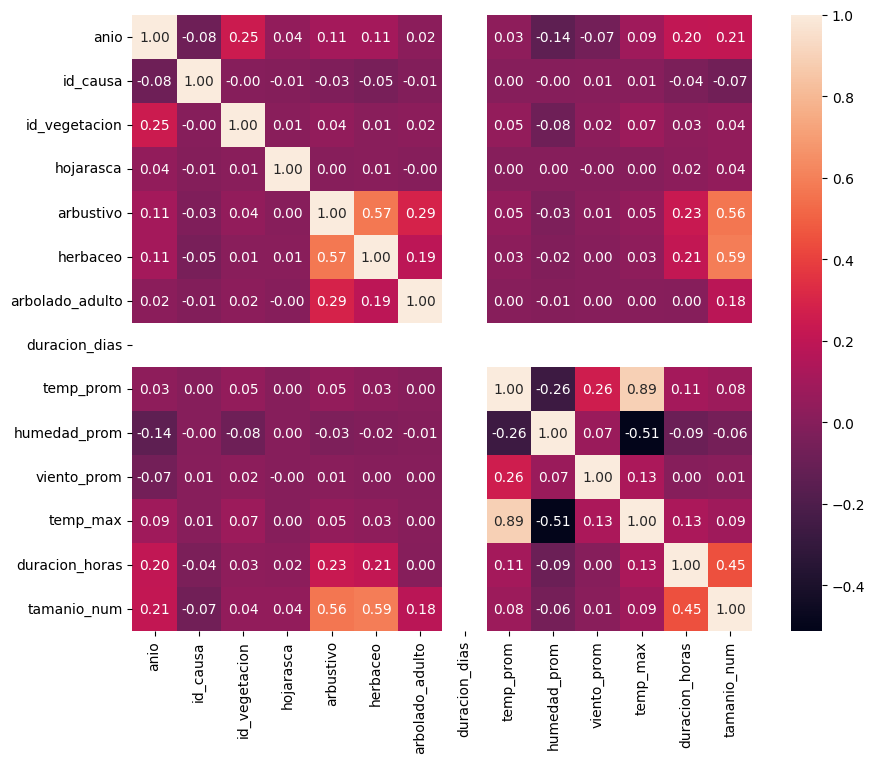

In [ ]:
corr = df.corr(numeric_only=True)
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(11,8))
sns.heatmap(corr, annot=True, fmt=".2f")
plt.show()

## Análisis de la duración de incendios

- Se encontró que la duración de los incendios forestales presenta mayor correlación con variables relacionadas a la vegetación, particularmente la cobertura arbustiva (r = 0.23) y herbácea (r = 0.21), lo que sugiere que la disponibilidad de material combustible influye significativamente en la persistencia del fuego.

- La temperatura mostró una relación positiva moderada con la duración (r ≈ 0.10–0.13), mientras que la humedad presentó una correlación negativa (r = -0.09), indicando que condiciones secas favorecen incendios más prolongados.

- La velocidad del viento no mostró una relación significativa con la duración, lo cual sugiere que su influencia podría estar más asociada a la propagación que a la persistencia del incendio.

## Análisis por categorías

Se agrupan variables por tamaño del incendio para analizar promedios.

Ejemplo:
- Temperatura promedio por tamaño
- Tipo de vegetación (arbustivo, herbáceo)

Objetivo:
Entender cómo cambian las variables según la magnitud del incendio.

Importancia:
Esto permite detectar patrones que no siempre se ven en la correlación.

In [64]:
corr["tamanio_num"].sort_values(ascending=False)

tamanio_num        1.000000
herbaceo           0.590709
arbustivo          0.563388
duracion_horas     0.449856
anio               0.212038
arbolado_adulto    0.184260
temp_max           0.086721
temp_prom          0.078534
hojarasca          0.043905
id_vegetacion      0.038799
viento_prom        0.012651
humedad_prom      -0.057730
id_causa          -0.071334
duracion_dias           NaN
Name: tamanio_num, dtype: float64

Los incendios más grandes están fuertemente asociados con la presencia de vegetación baja (herbácea y arbustiva), lo que indica que la disponibilidad de material combustible es el principal factor en la severidad del incendio.

In [65]:
df.groupby("tamanio")["temp_max"].mean()

tamanio
0 a 5 Hectáreas          28.453365
11 a 20 Hectáreas        29.206461
21 a 50 Hectáreas        29.303196
51 a 100 Hectáreas       29.536684
6 a 10 Hectáreas         28.979776
Mayor a 100 Hectáreas    29.405031
Name: temp_max, dtype: float32

In [66]:
df["tamanio"] = df["tamanio"].str.replace("06 a 10", "6 a 10")

In [ ]:
df.groupby("tamanio")["arbustivo"].mean()
df.groupby("tamanio")["herbaceo"].mean()

tamanio
0 a 5 Hectáreas            0.481921
11 a 20 Hectáreas          6.369916
21 a 50 Hectáreas         13.548015
51 a 100 Hectáreas        29.264572
6 a 10 Hectáreas           2.509794
Mayor a 100 Hectáreas    161.298019
Name: herbaceo, dtype: float32

El análisis por categorías de tamaño mostró una tendencia creciente en la temperatura máxima conforme aumenta la extensión del incendio. Los incendios de mayor tamaño (>100 ha) presentan temperaturas promedio superiores en comparación con incendios pequeños (0–5 ha), lo que sugiere que condiciones térmicas elevadas favorecen la propagación del fuego.

Sin embargo, la correlación global entre temperatura y tamaño fue baja, indicando que la temperatura por sí sola no explica completamente la severidad del incendio, sino que actúa en conjunto con otros factores como la vegetación.

In [68]:
corr["tamanio_num"]

anio               0.212038
id_causa          -0.071334
id_vegetacion      0.038799
hojarasca          0.043905
arbustivo          0.563388
herbaceo           0.590709
arbolado_adulto    0.184260
duracion_dias           NaN
temp_prom          0.078534
humedad_prom      -0.057730
viento_prom        0.012651
temp_max           0.086721
duracion_horas     0.449856
tamanio_num        1.000000
Name: tamanio_num, dtype: float64

El análisis de correlación mostró que las variables más influyentes en el tamaño de los incendios forestales son aquellas relacionadas con la vegetación, particularmente la cobertura herbácea (r = 0.59) y arbustiva (r = 0.56), lo que evidencia que la disponibilidad de material combustible es el principal determinante de la severidad del incendio.

Asimismo, la duración del incendio presentó una correlación significativa (r = 0.45), indicando que incendios más prolongados tienden a alcanzar mayores dimensiones.

En contraste, las variables climáticas como la temperatura (r ≈ 0.08) y la humedad (r ≈ -0.05) mostraron una influencia menor en el tamaño del incendio, lo que sugiere que su papel está más relacionado con la ocurrencia del evento que con su magnitud.